In [1]:
# Import other libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs

# Options for plots
plt.rcParams['figure.figsize'] = (10, 6)
sbs.set('paper')

# Import litstudy
path = os.path.abspath(os.path.join('..'))
if path not in sys.path:
    sys.path.append(path)

%pip install litstudy
import litstudy

Note: you may need to restart the kernel to use updated packages.


10515 RAC papers loaded from CSV
<592 documents>
<9923 documents>


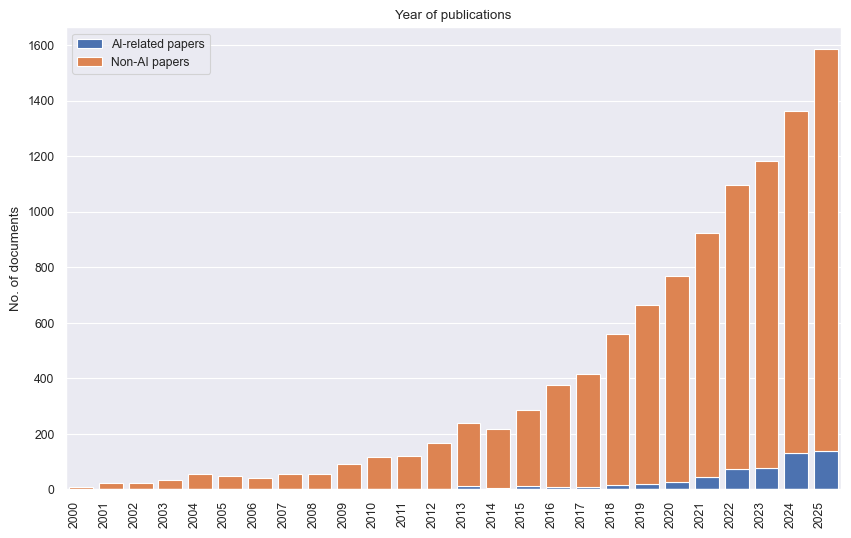

In [3]:
# Load CSV file
# docs_hea = litstudy.load_scopus_csv('HEA_17624.csv')
# print(len(docs_hea), 'HEA papers loaded from CSV')
docs_rac = litstudy.load_scopus_csv('RAC_10515.csv')
print(len(docs_rac), 'RAC papers loaded from CSV')

def paper_separation(docs):
    # Build corpus and topic model, make some plottings
    corpus = litstudy.build_corpus(docs, ngram_threshold=0.9)
    #plt.figure(figsize=(20,3))
    #litstudy.plot_word_distribution(corpus,limit=50,title="Top words", vertical=True, label_rotation=45);
    num_topics=20
    topic_model = litstudy.train_nmf_model(corpus,num_topics,max_iter=250)
    #plt.figure(figsize=(20,5))
    #litstudy.plot_topic_clouds(topic_model,ncols=5)

    # Verify the topic modelling results
    ML_topic = topic_model.best_topic_for_token('machine_learning')
    # for doc_id in topic_model.best_documents_for_topic(ML_topic, limit=10):
    #    print(docs[int(doc_id)].title)

    # Add the tags of ml_topic based on the classification above 
    threshold = 0.2
    ml_topic = topic_model.doc2topic[:, ML_topic] > threshold

    docs = docs.add_property('ml_topic', ml_topic)

    groups = {
        'AI-related papers': 'ml_topic',
        'Non-AI papers': 'not ml_topic',
    }
    
    litstudy.plot_year_histogram(docs, groups=groups, stacked=True, vertical = True)

    # splitting the documents into ai & non-ai
    indices_ai = [i for i, val in enumerate(ml_topic) if val == True ]
    indices_nai = [i for i, val in enumerate(ml_topic) if val == False ]

    docs_m_ai = docs.select(indices_ai)
    docs_m_nai = docs.select(indices_nai)
    print(docs_m_ai)
    print(docs_m_nai)

    return docs_m_ai, docs_m_nai

# [hea_docs_ai, hea_docs_nai] = paper_separation(docs_hea)
[rac_docs_ai, rac_docs_nai] = paper_separation(docs_rac)

17624 HEA papers loaded from CSV
<866 documents>
<16758 documents>


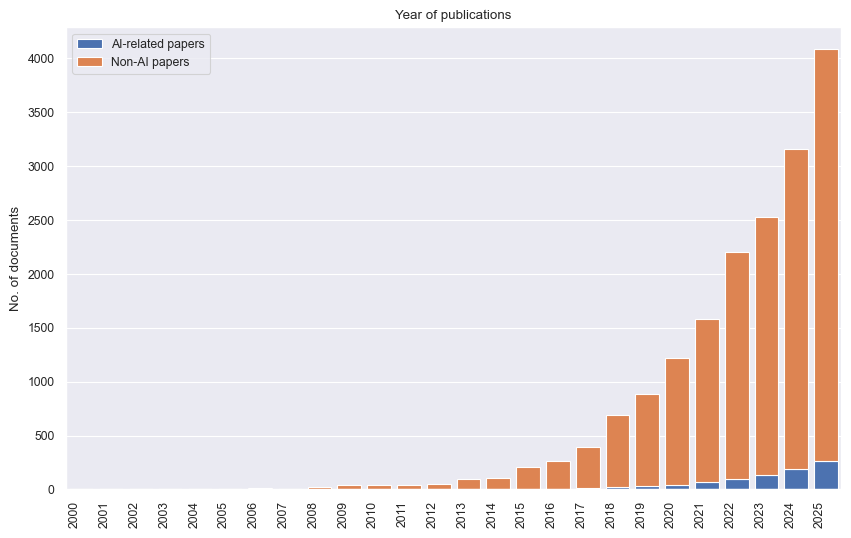

In [4]:
# Load CSV file
docs_hea = litstudy.load_scopus_csv('HEA_17624.csv')
print(len(docs_hea), 'HEA papers loaded from CSV')

def paper_separation(docs):
    # Build corpus and topic model, make some plottings
    corpus = litstudy.build_corpus(docs, ngram_threshold=0.9)
    num_topics=20
    topic_model = litstudy.train_nmf_model(corpus,num_topics,max_iter=250)

    # Verify the topic modelling results
    ML_topic = topic_model.best_topic_for_token('machine_learning')

    # Add the tags of ml_topic based on the classification above 
    threshold = 0.2
    ml_topic = topic_model.doc2topic[:, ML_topic] > threshold

    docs = docs.add_property('ml_topic', ml_topic)

    groups = {
        'AI-related papers': 'ml_topic',
        'Non-AI papers': 'not ml_topic',
    }
    
    litstudy.plot_year_histogram(docs, groups=groups, stacked=True, vertical = True)

    # splitting the documents into ai & non-ai
    indices_ai = [i for i, val in enumerate(ml_topic) if val == True ]
    indices_nai = [i for i, val in enumerate(ml_topic) if val == False ]

    docs_m_ai = docs.select(indices_ai)
    docs_m_nai = docs.select(indices_nai)
    print(docs_m_ai)
    print(docs_m_nai)

    return docs_m_ai, docs_m_nai

[hea_docs_ai, hea_docs_nai] = paper_separation(docs_hea)

In [9]:
import pickle
# save the documents as file
# with open('HEA_Docs_ai.pkl','wb') as file:
#    pickle.dump(hea_docs_ai,file)

# with open('HEA_Docs_nai.pkl','wb') as file:
#    pickle.dump(hea_docs_nai,file)

with open('RAC_Docs_ai.pkl','wb') as file:
    pickle.dump(rac_docs_ai,file)

with open('RAC_Docs_nai.pkl','wb') as file:
    pickle.dump(rac_docs_nai,file)

In [10]:
# Test loading the saved files, remember to reload the first cell for litstudy, cheers!
docs_ai = []
# with open('HEA_Docs_ai.pkl','rb') as f:
with open('RAC_Docs_ai.pkl','rb') as f:
    docs_ai = pickle.load(f)

print(docs_ai)

# load the saved files, remember to reload the first cell for litstudy, cheers!
docs_nai = []
# with open('HEA_Docs_nai.pkl','rb') as f:
with open('RAC_Docs_nai.pkl','rb') as f:
    docs_nai = pickle.load(f)

print(docs_nai)

<592 documents>
<9923 documents>


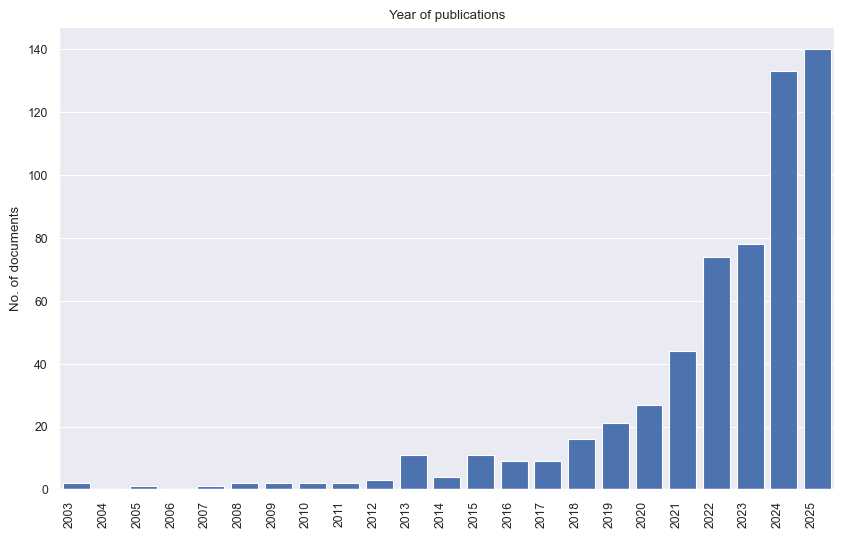

In [11]:
litstudy.plot_year_histogram(docs_ai, vertical = True);

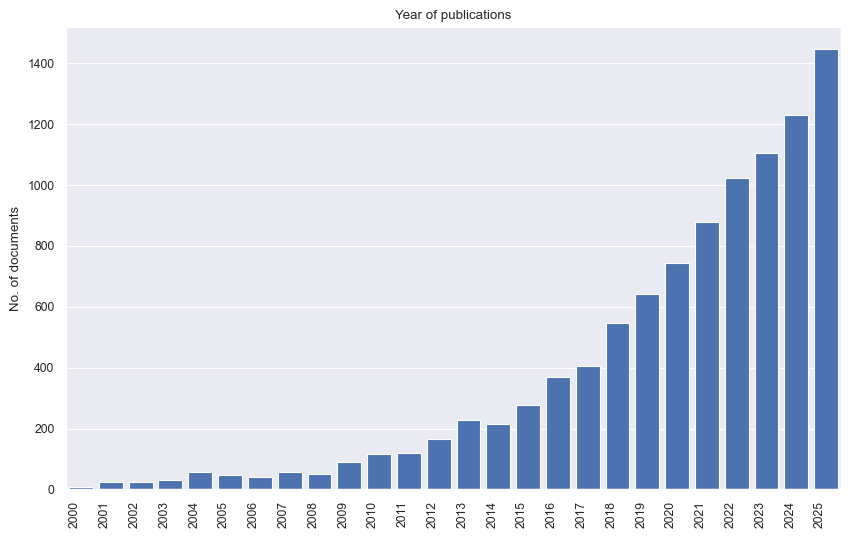

In [12]:
litstudy.plot_year_histogram(docs_nai, vertical = True);

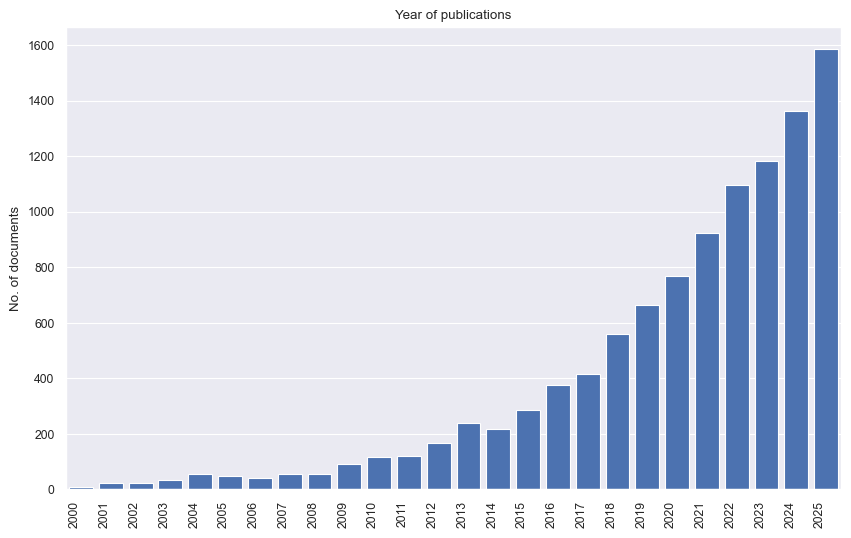

In [18]:
litstudy.plot_year_histogram(docs_rac, vertical = True);